In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap

# For interactive widgets in VS Code
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Reproducibility
np.random.seed(42)

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
sns.set_palette("husl")

print("✅ All imports successful.")
print(f"numpy  : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"sklearn: {__import__('sklearn').__version__}")
print(f"xgboost: {xgb.__version__}")


✅ All imports successful.
numpy  : 2.4.2
pandas : 2.3.3
sklearn: 1.8.0
xgboost: 3.3.0


In [2]:
import os
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                         "nasa_tps_materials.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nMaterials: {df['material'].nunique()} unique")
print(f"Material classes: {df['material_class'].unique()}")
print(f"\nMissing thermal conductivity values:")
print(df[df['thermal_conductivity'].isna()][['material','state','temperature']])
print(f"\nTotal missing k values: {df['thermal_conductivity'].isna().sum()}")
print(f"\nColumn names: {df.columns.tolist()}")


Dataset shape: (71, 11)

Materials: 12 unique
Material classes: ['ablator' 'ceramic_ablator' 'ceramic_tile' 'blanket' 'RCC']

Missing thermal conductivity values:
     material   state  temperature
32  SIRCA-25L  virgin          300
33  SIRCA-25L  virgin          600
38  SIRCA-15F  virgin          300
39  SIRCA-15F  virgin          600

Total missing k values: 4

Column names: ['material', 'state', 'temperature', 'density', 'specific_heat', 'emissivity', 'material_class', 'thermal_conductivity', 'max_use_temp', 'cost_per_m2', 'installation_time_hr']


# **PLOTTING THE DATA**

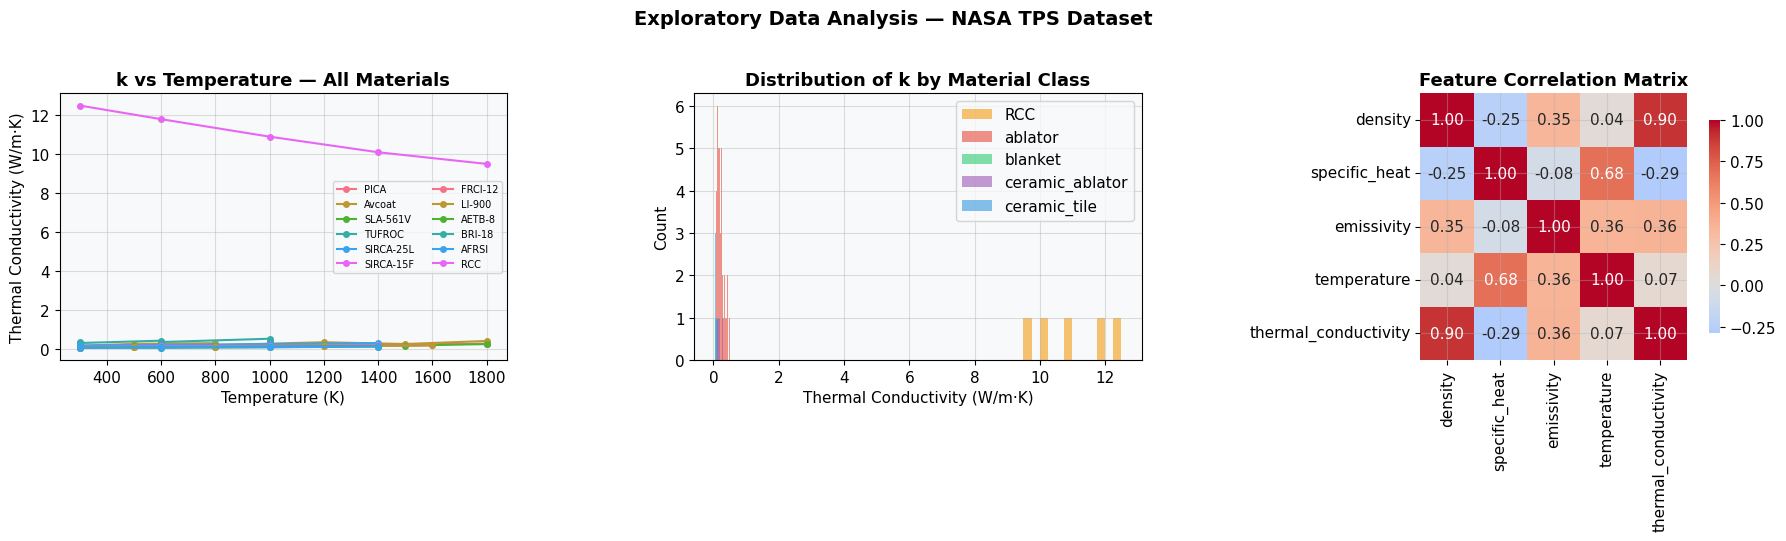

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_known = df.dropna(subset=['thermal_conductivity'])
for mat in df_known['material'].unique():
    sub = df_known[df_known['material'] == mat].sort_values('temperature')
    axes[0].plot(sub['temperature'], sub['thermal_conductivity'],
                 marker='o', markersize=4, label=mat, linewidth=1.5)
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Thermal Conductivity (W/m·K)')
axes[0].set_title('k vs Temperature — All Materials')
axes[0].legend(fontsize=7, ncol=2)

df_known_class = df_known.groupby('material_class')['thermal_conductivity'].apply(list)
colors = {'ablator': '#e74c3c', 'ceramic_tile': '#3498db',
          'blanket': '#2ecc71', 'RCC': '#f39c12', 'ceramic_ablator': '#9b59b6'}
for cls, vals in df_known_class.items():
    axes[1].hist(vals, bins=12, alpha=0.6, label=cls, color=colors.get(cls, 'gray'))
axes[1].set_xlabel('Thermal Conductivity (W/m·K)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of k by Material Class')
axes[1].legend()

num_cols = ['density', 'specific_heat', 'emissivity', 'temperature', 'thermal_conductivity']
corr = df_known[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[2], square=True, cbar_kws={'shrink': 0.8})
axes[2].set_title('Feature Correlation Matrix')

plt.suptitle('Exploratory Data Analysis — NASA TPS Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


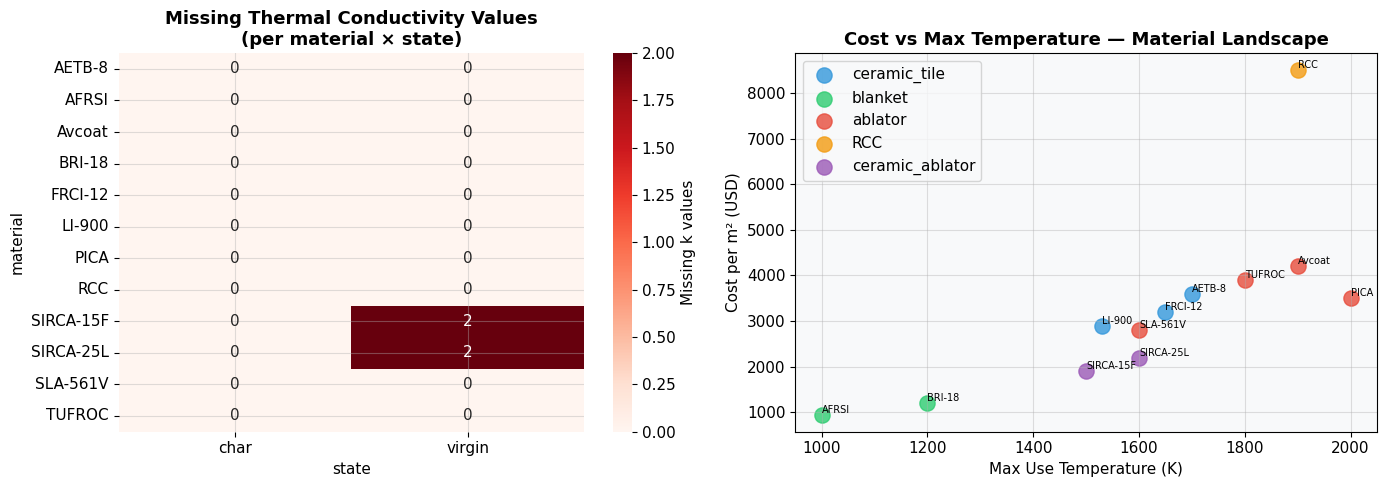

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing data heatmap
miss = df.pivot_table(index='material', columns='state',
                      values='thermal_conductivity',
                      aggfunc=lambda x: x.isna().sum())
miss = miss.fillna(0)
sns.heatmap(miss, annot=True, fmt='.0f', cmap='Reds',
            ax=axes[0], cbar_kws={'label': 'Missing k values'})
axes[0].set_title('Missing Thermal Conductivity Values\n(per material × state)')

# Cost vs Max Temp scatter (one row per material — take mode)
mat_summary = df.groupby('material').agg(
    cost=('cost_per_m2', 'first'),
    max_temp=('max_use_temp', 'first'),
    mat_class=('material_class', 'first')
).reset_index()

for cls in mat_summary['mat_class'].unique():
    sub = mat_summary[mat_summary['mat_class'] == cls]
    axes[1].scatter(sub['max_temp'], sub['cost'], label=cls,
                    s=120, alpha=0.8, color=colors.get(cls, 'gray'))
    for _, row in sub.iterrows():
        axes[1].annotate(row['material'], (row['max_temp'], row['cost']),
                         fontsize=7, ha='left', va='bottom')
axes[1].set_xlabel('Max Use Temperature (K)')
axes[1].set_ylabel('Cost per m² (USD)')
axes[1].set_title('Cost vs Max Temperature — Material Landscape')
axes[1].legend()

plt.tight_layout()
plt.show()

# **FEATURE ENGINEERING & SCOPE DEFINITION**

In [ ]:
HIGH_CONDUCTIVITY_EXCLUSIONS = [
    'RCC', 'RCC(Composite)', 'RCC (Coated)',
    'advanced Carbon Carbon composite',
    'C/SiC Composite', 'C/SiC (Carbon/Silicon-Carbide)'
]

df_stage1 = df[
    ~df['material'].isin(HIGH_CONDUCTIVITY_EXCLUSIONS) &
    df['thermal_conductivity'].notna()
].copy()
(RCC kept, missing k filled later)

df_stage2_base = df.copy()

anomaly_check = df[df['specific_heat'] < 10]
if not anomaly_check.empty:
    print("⚠️  Anomalous specific_heat entries (< 10 J/kg·K) — excluded via scope restriction:")
    print(anomaly_check[['material','specific_heat','temperature']])

print("\n=== Dataset Split ===")
print(f"Full dataset       : {len(df)} rows, {df['material'].nunique()} materials")
print(f"Stage 1 (insulating): {len(df_stage1)} rows, {df_stage1['material'].nunique()} materials")
print(f"Stage 2 (all)       : {len(df_stage2_base)} rows, {df_stage2_base['material'].nunique()} materials")
print(f"\nExcluded from Stage 1:")
for m in HIGH_CONDUCTIVITY_EXCLUSIONS:
    count = len(df[df['material'] == m])
    if count > 0:
        print(f"  {m}: {count} rows, "
              f"k={df[df['material']==m]['thermal_conductivity'].mean():.2f} W/m·K (mean)")



=== Dataset Split ===
Full dataset       : 71 rows, 12 materials
Stage 1 (insulating): 62 rows, 11 materials
Stage 2 (all)       : 71 rows, 12 materials

Excluded from Stage 1:
  RCC: 5 rows, k=10.96 W/m·K (mean)


In [ ]:

df_stage1 = df_stage1.copy()
df_stage1['temperature_sq']  = df_stage1['temperature'] ** 2
df_stage1['vol_heat_cap']    = df_stage1['density'] * df_stage1['specific_heat']

FEATURES = [
    'temperature',      
    'temperature_sq',   
    'density',          
    'specific_heat',    
    'vol_heat_cap',   
    'emissivity'        
]
TARGET = 'thermal_conductivity'

X = df_stage1[FEATURES].values
y = np.log1p(df_stage1[TARGET].values)   
groups = df_stage1['material'].values    

print(f"Stage 1 training set : {X.shape[0]} rows × {X.shape[1]} features")
print(f"Unique material groups: {len(np.unique(groups))}")
print(f"Target (log-scale)   : min={y.min():.3f}  max={y.max():.3f}  mean={y.mean():.3f}")
print(f"\nFeatures:")
for i, f in enumerate(FEATURES):
    vals = df_stage1[f]
    print(f"  {f:<20} min={vals.min():.3f}  max={vals.max():.3f}  mean={vals.mean():.3f}")


Stage 1 training set : 62 rows × 6 features
Unique material groups: 11
Target (log-scale)   : min=0.037  max=0.412  mean=0.154

Features:
  temperature          min=300.000  max=1800.000  mean=850.000
  temperature_sq       min=90000.000  max=3240000.000  mean=943709.677
  density              min=130.000  max=890.000  mean=294.145
  specific_heat        min=670.000  max=1500.000  mean=1079.548
  vol_heat_cap         min=96480.000  max=934500.000  mean=318226.161
  emissivity           min=0.780  max=0.940  mean=0.866


In [ ]:
models = {
    'Ridge'        : Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost'      : xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, random_state=42, verbosity=0)
}

gkf = GroupKFold(n_splits=5)
results = {}   

print("=" * 65)
for model_name, model in models.items():
    fold_rmse, fold_r2 = [], []
    print(f"\n{model_name}")

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]


        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2   = r2_score(y_test, y_pred)
        fold_rmse.append(rmse)
        fold_r2.append(r2)

        held_out = np.unique(groups[test_idx])
        print(f"  Fold {fold+1}: RMSE={rmse:.4f}  R²={r2:.4f}")
        print(f"  Held-out materials: {held_out}")
        print(f"  {'-'*52}")

    mean_rmse = float(np.mean(fold_rmse))
    std_rmse  = float(np.std(fold_rmse))
    mean_r2   = float(np.mean(fold_r2))
    std_r2    = float(np.std(fold_r2))

    results[model_name] = {'mean_rmse': mean_rmse, 'std_rmse': std_rmse,
                            'mean_r2': mean_r2,   'std_r2': std_r2,
                            'fold_rmse': fold_rmse, 'fold_r2': fold_r2}

    print(f"  ► Mean RMSE : {mean_rmse:.4f} ± {std_rmse:.4f}  (log scale)")
    print(f"  ► Mean R²   : {mean_r2:.4f} ± {std_r2:.4f}")

print("\n" + "=" * 65)

# Select best model by mean R²
best_model_name = max(results, key=lambda m: results[m]['mean_r2'])
print(f"\n🏆 Best model: {best_model_name}  "
      f"(Mean R² = {results[best_model_name]['mean_r2']:.4f})")



Ridge
  Fold 1: RMSE=0.0229  R²=0.8326
  Held-out materials: ['AFRSI' 'PICA']
  ----------------------------------------------------
  Fold 2: RMSE=0.0144  R²=0.9570
  Held-out materials: ['Avcoat' 'SIRCA-15F']
  ----------------------------------------------------
  Fold 3: RMSE=0.0278  R²=0.5500
  Held-out materials: ['BRI-18' 'SLA-561V']
  ----------------------------------------------------
  Fold 4: RMSE=0.0418  R²=0.8643
  Held-out materials: ['AETB-8' 'SIRCA-25L' 'TUFROC']
  ----------------------------------------------------
  Fold 5: RMSE=0.0158  R²=0.8441
  Held-out materials: ['FRCI-12' 'LI-900']
  ----------------------------------------------------
  ► Mean RMSE : 0.0245 ± 0.0099  (log scale)
  ► Mean R²   : 0.8096 ± 0.1370

Random Forest
  Fold 1: RMSE=0.0280  R²=0.7509
  Held-out materials: ['AFRSI' 'PICA']
  ----------------------------------------------------
  Fold 2: RMSE=0.0629  R²=0.1763
  Held-out materials: ['Avcoat' 'SIRCA-15F']
  -----------------------------

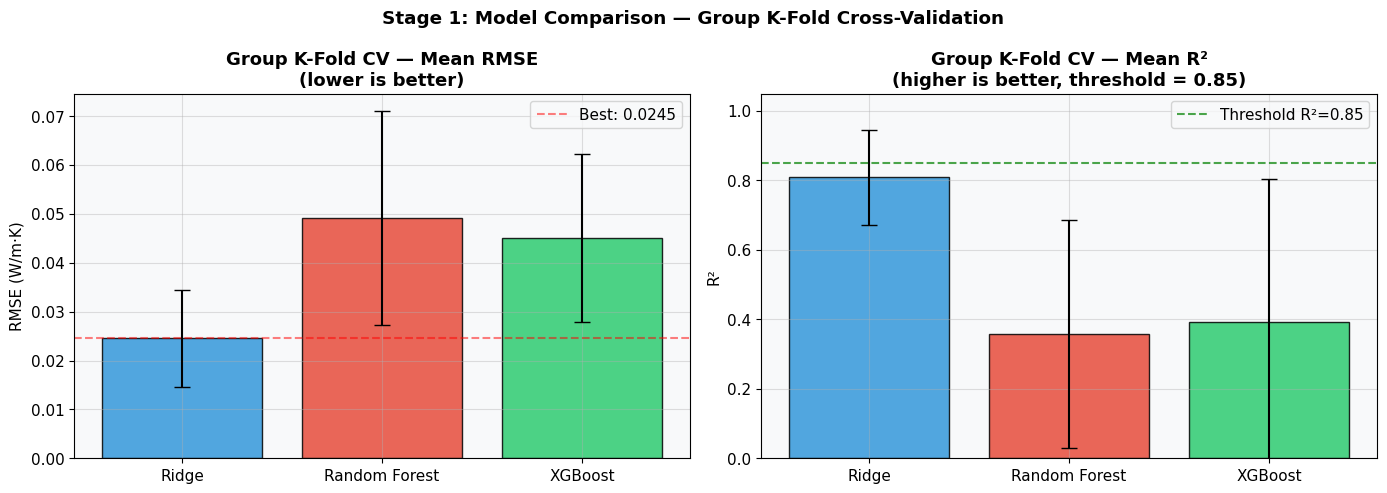


🏆 Best model: Ridge  (R² = 0.8096)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
mean_rmse = [results[m]['mean_rmse'] for m in model_names]
std_rmse  = [results[m]['std_rmse']  for m in model_names]
mean_r2   = [results[m]['mean_r2']   for m in model_names]
std_r2    = [results[m]['std_r2']    for m in model_names]
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(model_names, mean_rmse, yerr=std_rmse, capsize=6,
            color=bar_colors, alpha=0.85, edgecolor='black')
axes[0].set_ylabel('RMSE (W/m·K)')
axes[0].set_title('Group K-Fold CV — Mean RMSE\n(lower is better)')
axes[0].axhline(y=min(mean_rmse), color='red', linestyle='--', alpha=0.5, label=f'Best: {min(mean_rmse):.4f}')
axes[0].legend()

axes[1].bar(model_names, mean_r2, yerr=std_r2, capsize=6,
            color=bar_colors, alpha=0.85, edgecolor='black')
axes[1].set_ylabel('R²')
axes[1].set_title('Group K-Fold CV — Mean R²\n(higher is better, threshold = 0.85)')
axes[1].axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='Threshold R²=0.85')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('Stage 1: Model Comparison — Group K-Fold Cross-Validation', fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = model_names[np.argmax(mean_r2)]
print(f"\n🏆 Best model: {best_model_name}  (R² = {max(mean_r2):.4f})")


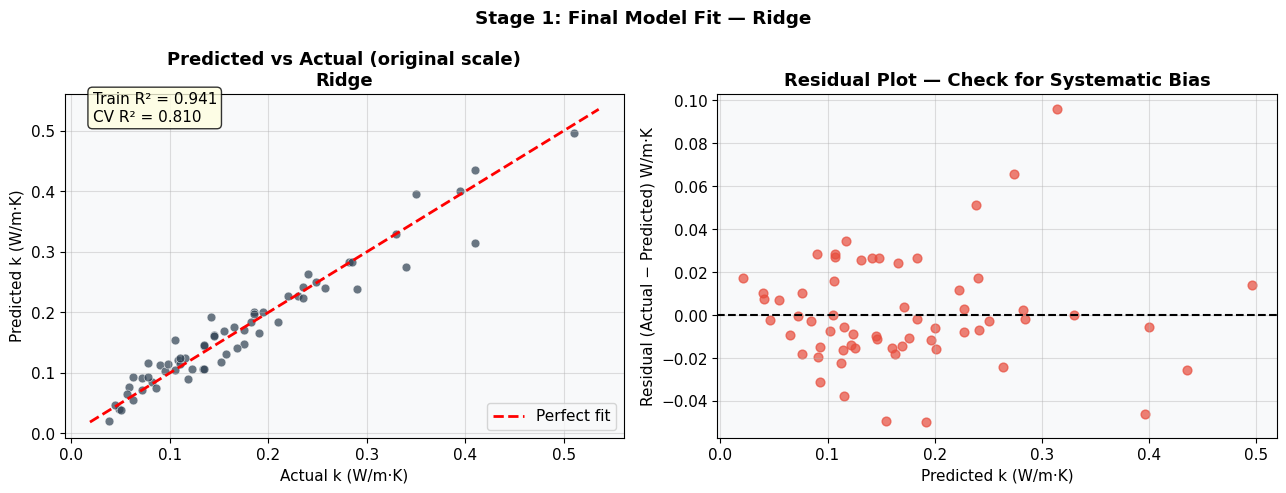


Residual mean  : 0.00033   (near 0 = no systematic bias)
Residual std   : 0.02515


In [ ]:
best_model = models[best_model_name]
scaler_final = StandardScaler()
X_sc_final = scaler_final.fit_transform(X)   

best_model.fit(X_sc_final, y)

y_pred_train = best_model.predict(X_sc_final)
train_r2     = r2_score(y, y_pred_train)
train_rmse   = np.sqrt(mean_squared_error(y, y_pred_train))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y_orig      = np.expm1(y)
y_pred_orig = np.expm1(y_pred_train)

axes[0].scatter(y_orig, y_pred_orig, alpha=0.7, s=40,
                color='#2c3e50', edgecolors='white', linewidth=0.5)
lims = [min(y_orig.min(), y_pred_orig.min())*0.9,
        max(y_orig.max(), y_pred_orig.max())*1.05]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual k (W/m·K)')
axes[0].set_ylabel('Predicted k (W/m·K)')
axes[0].set_title(f'Predicted vs Actual (original scale)\n{best_model_name}')
axes[0].legend()
axes[0].text(0.05, 0.92, f'Train R² = {train_r2:.3f}\nCV R² = {results[best_model_name]["mean_r2"]:.3f}',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

residuals = y_orig - y_pred_orig
axes[1].scatter(y_pred_orig, residuals, alpha=0.7, s=40, color='#e74c3c')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted k (W/m·K)')
axes[1].set_ylabel('Residual (Actual − Predicted) W/m·K')
axes[1].set_title('Residual Plot — Check for Systematic Bias')

plt.suptitle(f'Stage 1: Final Model Fit — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()
print("\nResidual mean  :", residuals.mean().round(5), "  (near 0 = no systematic bias)")
print("Residual std   :", residuals.std().round(5))

In [ ]:
df_missing = df[
    df['thermal_conductivity'].isna() &
    ~df['material'].isin(HIGH_CONDUCTIVITY_EXCLUSIONS)
].copy()

if df_missing.empty:
    print("ℹ️  No missing k values found in insulating materials.")
    df_complete = df.copy()
else:
  
    df_missing['temperature_sq'] = df_missing['temperature'] ** 2
    df_missing['vol_heat_cap']   = df_missing['density'] * df_missing['specific_heat']

    X_missing = df_missing[FEATURES].values
    X_missing_sc = scaler_final.transform(X_missing)
    log_k_pred   = best_model.predict(X_missing_sc)
    k_pred       = np.expm1(log_k_pred)   # reverse log1p transform

    df_missing['thermal_conductivity'] = k_pred

    print("✅ Predicted thermal conductivity for missing entries:")
    print(df_missing[['material','state','temperature','thermal_conductivity']]
          .to_string(index=False))

    df_complete = df.copy()
    # Engineer features in full df for consistent merge
    df_complete['temperature_sq'] = df_complete['temperature'] ** 2
    df_complete['vol_heat_cap']   = df_complete['density'] * df_complete['specific_heat']
    df_complete.loc[df_complete['thermal_conductivity'].isna(),
                    'thermal_conductivity'] = k_pred

    completeness = df_complete['thermal_conductivity'].notna().mean() * 100
    print(f"\nDataset completeness after Stage 1: {completeness:.1f}%")
    if completeness < 100:
        still_missing = df_complete[df_complete['thermal_conductivity'].isna()]
        print("Still missing (high-k exclusions — handled separately in Stage 2):")
        print(still_missing[['material','temperature']].to_string())


✅ Predicted thermal conductivity for missing entries:
 material  state  temperature  thermal_conductivity
SIRCA-25L virgin          300              0.075439
SIRCA-25L virgin          600              0.102694
SIRCA-15F virgin          300              0.021664
SIRCA-15F virgin          600              0.045870

Dataset completeness after Stage 1: 100.0%


In [ ]:
mat_score_df = df_complete.groupby('material').agg(
    mean_k           = ('thermal_conductivity', 'mean'),
    min_k            = ('thermal_conductivity', 'min'),
    max_use_temp     = ('max_use_temp',        'first'),
    cost_per_m2      = ('cost_per_m2',         'first'),
    install_time     = ('installation_time_hr', 'first'),
    material_class   = ('material_class',       'first'),
).reset_index()

print("Material summary for scoring:")
print(mat_score_df.to_string(index=False))

Material summary for scoring:
 material    mean_k    min_k  max_use_temp  cost_per_m2  install_time  material_class
   AETB-8  0.072000 0.044000          1700         3600            18    ceramic_tile
    AFRSI  0.066250 0.038000          1000          950             6         blanket
   Avcoat  0.255625 0.145000          1900         4200            22         ablator
   BRI-18  0.096750 0.062000          1200         1200             8         blanket
  FRCI-12  0.109000 0.058000          1650         3200            16    ceramic_tile
   LI-900  0.097200 0.048000          1530         2900            16    ceramic_tile
     PICA  0.166700 0.090000          2000         3500            18         ablator
      RCC 10.960000 9.500000          1900         8500            35             RCC
SIRCA-15F  0.101256 0.021664          1500         1900            12 ceramic_ablator
SIRCA-25L  0.176355 0.075439          1600         2200            14 ceramic_ablator
 SLA-561V  0.147750 0.08

In [ ]:
MISSION_WEIGHTS = {
    'single_use': {'w_thermal': 0.40, 'w_temp': 0.40, 'w_cost': 0.15, 'w_install': 0.05},
    'multi_use':  {'w_thermal': 0.30, 'w_temp': 0.25, 'w_cost': 0.20, 'w_install': 0.25},
    'budget':     {'w_thermal': 0.20, 'w_temp': 0.30, 'w_cost': 0.40, 'w_install': 0.10},
}

def normalise_inverse(series, clip_zero=True):
    inv = 1.0 / series.clip(lower=1e-6)
    mn, mx = inv.min(), inv.max()
    if mx == mn:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (inv - mn) / (mx - mn)

def normalise(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

def score_materials(mission_temp_K, mission_type, budget_per_m2):
    df_s = mat_score_df.copy()

    df_s = df_s[df_s['max_use_temp'] >= mission_temp_K].copy()
    if df_s.empty:
        return pd.DataFrame({'material': [], 'score': []})

    df_s = df_s[df_s['cost_per_m2'] <= budget_per_m2].copy()
    if df_s.empty:
        return pd.DataFrame({'material': [], 'score': [], 'note': ['No materials within budget']})

    df_s['ThermalScore']      = normalise_inverse(df_s['mean_k'])
    df_s['TemperatureScore']  = normalise(
        (df_s['max_use_temp'] - mission_temp_K).clip(lower=0) / mission_temp_K
    )
    df_s['CostScore']         = normalise_inverse(df_s['cost_per_m2'])
    df_s['InstallationScore'] = normalise_inverse(df_s['install_time'])

    w = MISSION_WEIGHTS[mission_type]
    df_s['Score'] = (
        w['w_thermal']  * df_s['ThermalScore'] +
        w['w_temp']     * df_s['TemperatureScore'] +
        w['w_cost']     * df_s['CostScore'] +
        w['w_install']  * df_s['InstallationScore']
    )

    return df_s.sort_values('Score', ascending=False).reset_index(drop=True)

ranking = score_materials(mission_temp_K=1800, mission_type='single_use', budget_per_m2=5000)

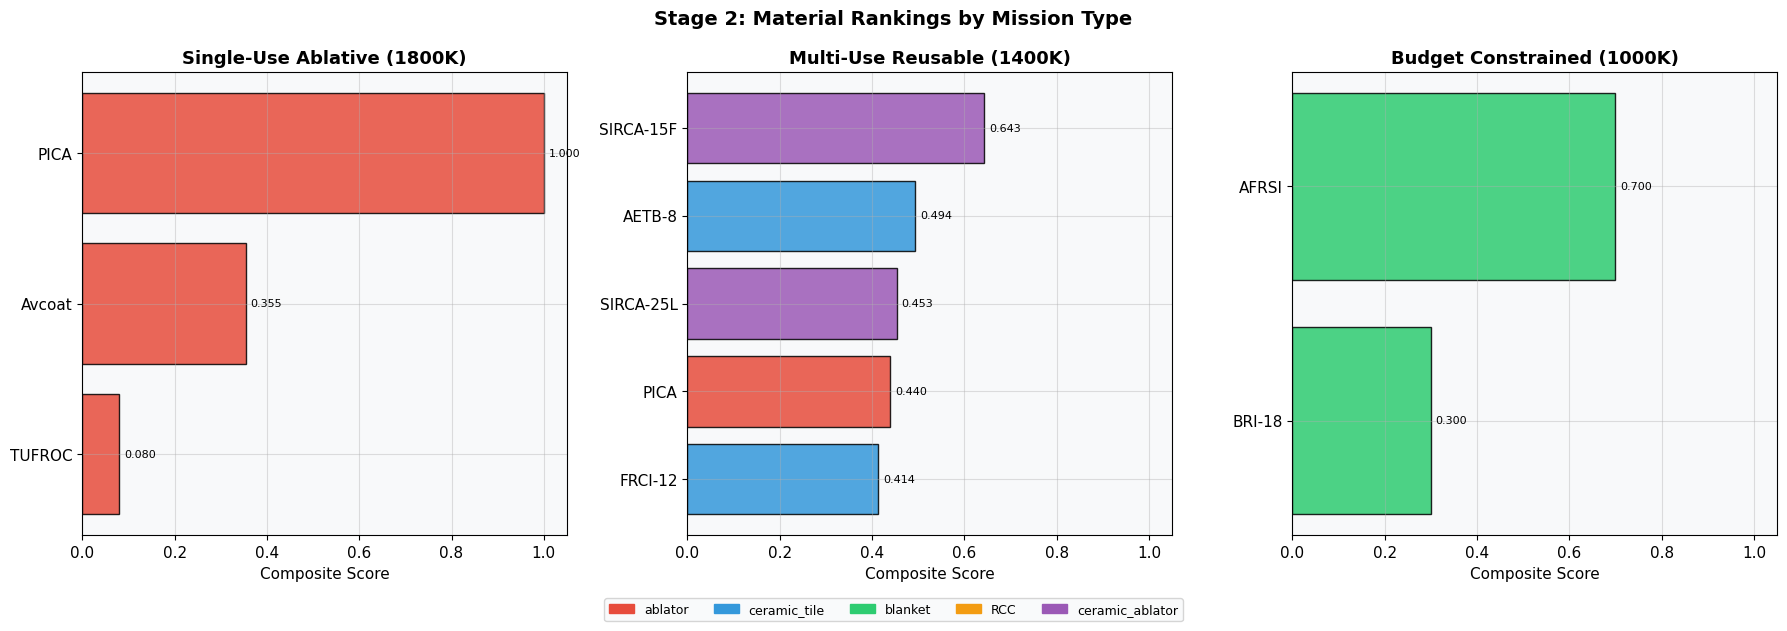

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mission_configs = [
    ('single_use', 1800, 5000, 'Single-Use Ablative (1800K)'),
    ('multi_use',  1400, 4500, 'Multi-Use Reusable (1400K)'),
    ('budget',     1000, 1500, 'Budget Constrained (1000K)'),
]
for ax, (mtype, mtemp, budget, title) in zip(axes, mission_configs):
    r = score_materials(mtemp, mtype, budget)
    if r.empty:
        ax.text(0.5, 0.5, 'No materials\nmeet constraints', ha='center', va='center')
        continue
    top5 = r.head(5)
    bar_c = [colors.get(c, 'gray') for c in top5['material_class']]
    bars = ax.barh(top5['material'][::-1], top5['Score'][::-1],
                   color=bar_c[::-1], edgecolor='black', alpha=0.85)
    ax.set_xlabel('Composite Score')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, score in zip(bars, top5['Score'][::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=8)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.suptitle('Stage 2: Material Rankings by Mission Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

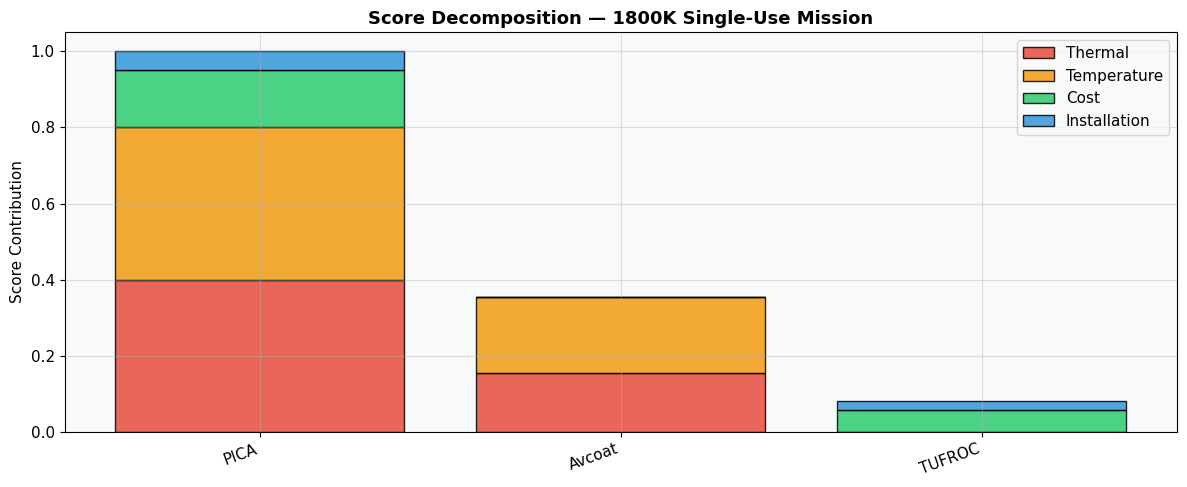

In [ ]:
r = score_materials(1800, 'single_use', 5000).head(8)
w = MISSION_WEIGHTS['single_use']

fig, ax = plt.subplots(figsize=(12, 5))
components = {
    'Thermal': w['w_thermal'] * r['ThermalScore'].values,
    'Temperature': w['w_temp'] * r['TemperatureScore'].values,
    'Cost': w['w_cost'] * r['CostScore'].values,
    'Installation': w['w_install'] * r['InstallationScore'].values,
}
comp_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
bottom = np.zeros(len(r))
for (label, vals), col in zip(components.items(), comp_colors):
    ax.bar(r['material'], vals, bottom=bottom, label=label, color=col, alpha=0.85, edgecolor='black')
    bottom += vals

ax.set_ylabel('Score Contribution')
ax.set_title('Score Decomposition — 1800K Single-Use Mission', fontweight='bold')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('stage2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


  0%|          | 0/62 [00:00<?, ?it/s]

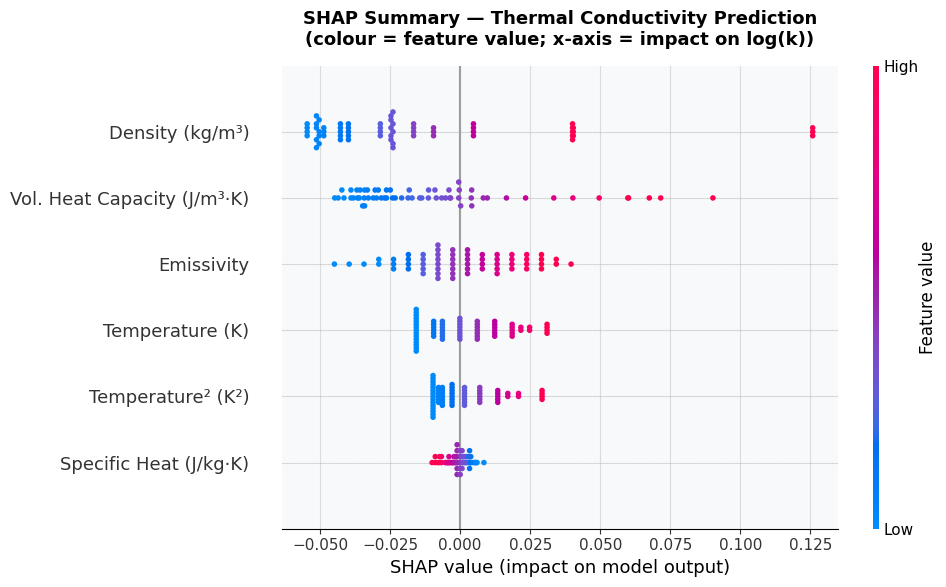


SHAP beeswarm saved → shap_summary.png


In [ ]:
FEATURE_DISPLAY_NAMES = [
    'Temperature (K)',
    'Temperature² (K²)',
    'Density (kg/m³)',
    'Specific Heat (J/kg·K)',
    'Vol. Heat Capacity (J/m³·K)',
    'Emissivity'
]
if best_model_name in ['XGBoost', 'Random Forest']:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_sc_final)
else:
    # Ridge: KernelExplainer on 30-sample background
    background  = shap.sample(X_sc_final, min(30, len(X_sc_final)))
    explainer   = shap.KernelExplainer(best_model.predict, background)
    shap_values = explainer.shap_values(X_sc_final, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc_final,
                  feature_names=FEATURE_DISPLAY_NAMES,
                  show=False, plot_size=None)
plt.title('SHAP Summary — Thermal Conductivity Prediction\n'          '(colour = feature value; x-axis = impact on log(k))',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSHAP summary saved → shap_summary.png")


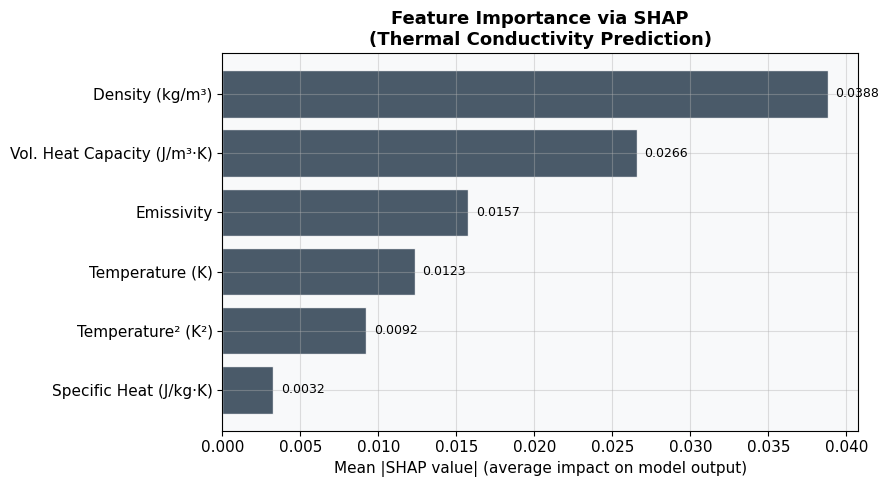


📊 Top 3 most impactful features:
  1. Density (kg/m³)           Mean |SHAP| = 0.0388
  2. Vol. Heat Capacity (J/m³·K) Mean |SHAP| = 0.0266
  3. Emissivity                Mean |SHAP| = 0.0157


In [ ]:
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEATURE_DISPLAY_NAMES, 'mean_abs_shap': mean_shap})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(shap_df['feature'], shap_df['mean_abs_shap'],
               color='#2c3e50', alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
ax.set_title('Feature Importance via SHAP\n(Thermal Conductivity Prediction)', fontweight='bold')
for bar, val in zip(bars, shap_df['mean_abs_shap']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 3 most impactful features:")
top3 = shap_df.sort_values('mean_abs_shap', ascending=False).head(3)
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {i}. {row['feature']:<25} Mean |SHAP| = {row['mean_abs_shap']:.4f}")


In [27]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/ridge_stage1.pkl")
joblib.dump(scaler, "models/scaler_stage1.pkl")

print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!
